# 163 minutos, o 45

Es el mismo coágulo, el mismo fármaco, el mismo cerdo. La diferencia: en el segundo caso hay un robot blando parado junto al tapón, batiendo cilios —como los que limpian tu tráquea— para empujar la sangre contra el coágulo.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Fang et al. (2026). *A miniature endovascular soft robot for active blood flow regulation in occluded vessels*. Nature Biomedical Engineering.
**DOI:** [10.1038/s41551-026-01771-y](https://doi.org/10.1038/s41551-026-01771-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-08-17-robot-endovascular-cilios-flujo/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/pTjdi9LV6dM)

## Qué hicieron

Cuando una arteria se tapa, el problema no termina en el tapón. Detrás de él la sangre casi deja de moverse, y sin movimiento el fármaco que disuelve coágulos —el tPA— llega solo por difusión. La difusión es lentísima, así que buena parte del coágulo nunca ve el fármaco.

El equipo de Fang construyó un robot blando de silicona (PDMS) con partículas magnéticas de neodimio (NdFeB): un chasis que se guía con un imán desde afuera y, encima, un tapete de cilios que baten en secuencia. Navegar y bombear van por separado — el robot llega al sitio, se queda quieto, y solo entonces empieza a mover fluido.

Lo midieron en dos escenarios: phantoms de vaso (tubos que imitan una bifurcación arterial, con sangre porcina) y cerdos vivos. Fang y su equipo lo proponen como concepto y lo validan en esos dos escenarios; nada de esto se midió en personas.

Lo que vamos a abrir son los Source Data de las Figs. 2–6 —las hojas con los números crudos que Nature publica junto al paper—: 13 hojas con los barridos de diseño y los dos experimentos con control.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FRECUENCIA_MAX_HZ = 20         # Frecuencia de batido a la que comparamos (Hz)
COBERTURA_DESTACADA = 180      # Ángulo de cobertura del tapete a resaltar (grados)
VENTANA_MESETA_MIN = 15        # Desde qué minuto consideramos "meseta" en la curva de tPA
FUENTE = 'Fuente: Fang et al. (2026), Nature Biomed. Eng. | Datos: Source Data Figs. 2-6'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_CONTEXTO = '#BBBBBB'

import os
import urllib.request
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from scipy import stats

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
SLUG = '2026-08-17-robot-endovascular-cilios-flujo'

# Estilo CaM: local -> /tmp -> GitHub raw
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)
os.makedirs('datos', exist_ok=True)


def cargar(nombre):
    """Carga un CSV local; si no está (p. ej. en Colab), lo baja del repo."""
    ruta = f'datos/{nombre}'
    if not os.path.exists(ruta):
        urllib.request.urlretrieve(f'{BASE}/papers/{SLUG}/datos/{nombre}', ruta)
    return pd.read_csv(ruta)


invivo    = cargar('recanalizacion_invivo.csv')
invitro   = cargar('recanalizacion_invitro.csv')
tpa       = cargar('tpa_concentracion.csv')
onda      = cargar('flujo_vs_frecuencia_onda.csv')
cobertura = cargar('flujo_vs_cobertura.csv')
fondo     = cargar('flujo_vs_frecuencia_fondo.csv')
iman      = cargar('robot_velocidad_iman.csv')
espaciado = cargar('flujo_espaciado_cilios.csv')

# numpy 1.26 no tiene trapezoid; numpy 2.x deprecó trapz
trapz = getattr(np, 'trapezoid', None) or np.trapz


def cohens_d(a, b):
    """d de Cohen para grupos independientes (varianza combinada)."""
    na, nb = len(a), len(b)
    s = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb - 1) * b.std(ddof=1) ** 2) / (na + nb - 2))
    return (a.mean() - b.mean()) / s


def p_permutacion(a, b):
    """p exacto a dos colas: enumera TODAS las reasignaciones de etiquetas."""
    todos = np.concatenate([a, b])
    obs = abs(np.mean(a) - np.mean(b))
    idx = list(range(len(todos)))
    diffs = []
    for c in combinations(idx, len(a)):
        ga = todos[list(c)]
        gb = todos[[i for i in idx if i not in c]]
        diffs.append(abs(ga.mean() - gb.mean()))
    diffs = np.array(diffs)
    return float(np.mean(diffs >= obs - 1e-9)), len(diffs)


print(f'Recanalización in vivo (cerdo):    {len(invivo)} mediciones en {invivo.condicion.nunique()} grupos')
print(f'Recanalización in vitro (phantom): {len(invitro)} mediciones en {invitro.condicion.nunique()} grupos')
print(f'tPA dentro del coágulo:            {len(tpa)} tiempos, 0-{tpa.tiempo_min.max():.0f} min')
print(f'Barrido de frecuencia (onda):      {len(onda)} puntos, 0-{onda.frecuencia_hz.max():.0f} Hz')
print(f'Barrido de cobertura del tapete:   {len(cobertura)} ángulos, {cobertura.cobertura_gamma_deg.min()}-{cobertura.cobertura_gamma_deg.max()} grados')
print(f'Flujo por velocidad de fondo:      {len(fondo)} combinaciones frecuencia x velocidad')
print()
print('Unidades: flujo y velocidades en mm/s, tiempos en min, tPA en ng/ml.')
print('Ojo: los mm/s de FLUJO (Figs. 3-4) y los mm/s de VELOCIDAD DEL ROBOT (Fig. 5c-e)')
print('son la misma unidad pero cosas distintas — nunca van en el mismo eje.')

Recanalización in vivo (cerdo):    6 mediciones en 2 grupos
Recanalización in vitro (phantom): 10 mediciones en 2 grupos
tPA dentro del coágulo:            11 tiempos, 0-50 min
Barrido de frecuencia (onda):      11 puntos, 0-20 Hz
Barrido de cobertura del tapete:   8 ángulos, 45-360 grados
Flujo por velocidad de fondo:      44 combinaciones frecuencia x velocidad

Unidades: flujo y velocidades en mm/s, tiempos en min, tPA en ng/ml.
Ojo: los mm/s de FLUJO (Figs. 3-4) y los mm/s de VELOCIDAD DEL ROBOT (Fig. 5c-e)
son la misma unidad pero cosas distintas — nunca van en el mismo eje.


Aquí está.

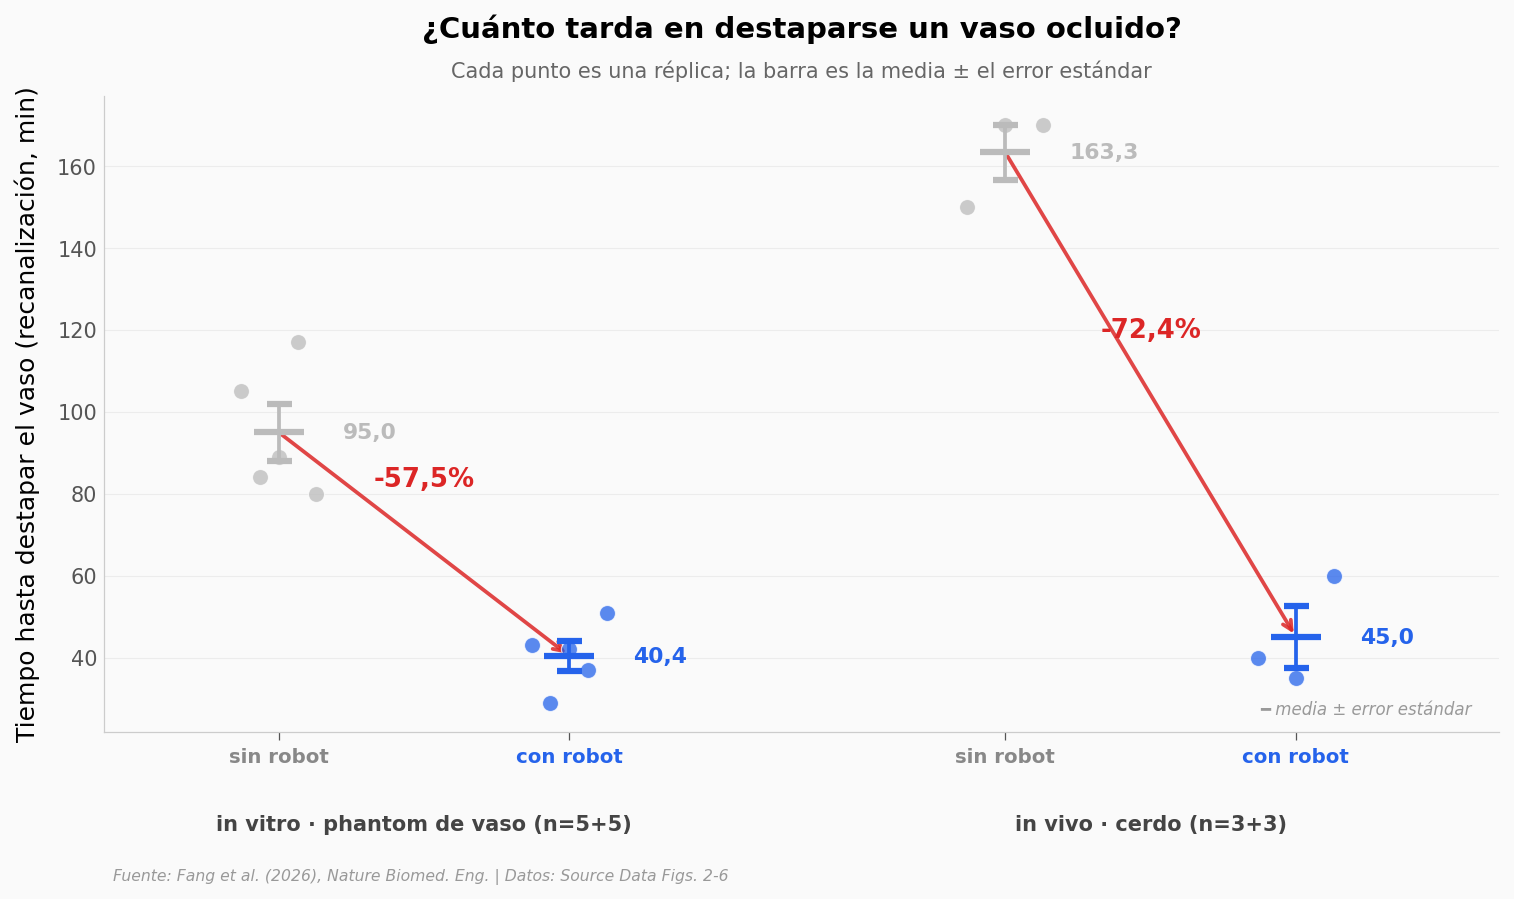

in vitro:  95.00 ± 15.54 min (n=5)  ->  40.40 ±  8.11 min (n=5)
          diferencia de medias = 54.60 min | reducción = 57.5% | ratio = 2.35x
          brecha entre el peor con robot (51 min) y el mejor sin robot (80 min) = 29 min
          Cohen's d = 4.40 | p exacto por permutación = 0.0079 (sobre 252 reasignaciones posibles)
          p mínimo alcanzable con este n = 0.0079

in vivo : 163.33 ± 11.55 min (n=3)  ->  45.00 ± 13.23 min (n=3)
          diferencia de medias = 118.33 min | reducción = 72.4% | ratio = 3.63x
          brecha entre el peor con robot (60 min) y el mejor sin robot (150 min) = 90 min
          Cohen's d = 9.53 | p exacto por permutación = 0.1000 (sobre 20 reasignaciones posibles)
          p mínimo alcanzable con este n = 0.1000



In [2]:
fig, ax = plt.subplots(figsize=(12, 5.5))
np.random.seed(42)

grupos = [
    ('sin robot', invitro.query('condicion == "sin_robot"').tiempo_min.values, COLOR_CONTEXTO),
    ('con robot', invitro.query('condicion == "con_robot"').tiempo_min.values, COLOR_DATOS),
    ('sin robot', invivo.query('condicion == "sin_robot"').tiempo_min.values, COLOR_CONTEXTO),
    ('con robot', invivo.query('condicion == "con_robot"').tiempo_min.values, COLOR_DATOS),
]
posiciones = [0, 1, 2.5, 3.5]

for (etiqueta, vals, color), pos in zip(grupos, posiciones):
    n = len(vals)
    x = np.linspace(pos - 0.13, pos + 0.13, n)
    np.random.shuffle(x)
    ax.scatter(x, vals, color=color, s=60, alpha=0.75,
               edgecolors='white', linewidths=0.6, zorder=5)
    media, sem = vals.mean(), vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(pos, media, yerr=sem, fmt='_', color=color, markersize=24,
                markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)
    ax.text(pos + 0.22, media, f'{media:.1f}'.replace('.', ','), fontsize=10.5,
            fontweight='bold', color=color, va='center', zorder=7)

# Flecha de reducción por régimen
for (p0, p1), v0, v1 in [((0, 1), grupos[0][1], grupos[1][1]),
                         ((2.5, 3.5), grupos[2][1], grupos[3][1])]:
    reduccion = 100 * (1 - v1.mean() / v0.mean())
    ax.annotate('', xy=(p1, v1.mean()), xytext=(p0, v0.mean()),
                arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.8, alpha=0.85))
    ax.text((p0 + p1) / 2, (v0.mean() + v1.mean()) / 2 + 14,
            f'-{reduccion:.1f}%'.replace('.', ','), ha='center', fontsize=12.5,
            fontweight='bold', color=COLOR_ALERTA)

ax.set_xticks(posiciones)
ax.set_xticklabels([g[0] for g in grupos], fontsize=9.5, fontweight='bold')
for tick, g in zip(ax.get_xticklabels(), grupos):
    tick.set_color(g[2] if g[2] != COLOR_CONTEXTO else '#888888')

trans = blended_transform_factory(ax.transData, ax.transAxes)
ax.text(0.5, -0.155, 'in vitro · phantom de vaso (n=5+5)', transform=trans,
        ha='center', fontsize=10, fontweight='bold', color='#444444')
ax.text(3.0, -0.155, 'in vivo · cerdo (n=3+3)', transform=trans,
        ha='center', fontsize=10, fontweight='bold', color='#444444')

ax.set_xlim(-0.6, 4.2)
ax.set_ylabel('Tiempo hasta destapar el vaso (recanalización, min)')
ax.set_title('¿Cuánto tarda en destaparse un vaso ocluido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es una réplica; la barra es la media ± el error estándar',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.text(0.98, 0.02, '━ media ± error estándar', transform=ax.transAxes, fontsize=8,
        color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.07, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_recanalizacion.png', dpi=200, bbox_inches='tight')
plt.show()

for nombre, df in [('in vitro', invitro), ('in vivo ', invivo)]:
    sin_r = df.query('condicion == "sin_robot"').tiempo_min.values
    con_r = df.query('condicion == "con_robot"').tiempo_min.values
    p, n_perm = p_permutacion(sin_r, con_r)
    print(f'{nombre}: {sin_r.mean():6.2f} ± {sin_r.std(ddof=1):5.2f} min (n={len(sin_r)})  ->  '
          f'{con_r.mean():5.2f} ± {con_r.std(ddof=1):5.2f} min (n={len(con_r)})')
    print(f'          diferencia de medias = {sin_r.mean() - con_r.mean():.2f} min '
          f'| reducción = {100 * (1 - con_r.mean() / sin_r.mean()):.1f}% '
          f'| ratio = {sin_r.mean() / con_r.mean():.2f}x')
    print(f'          brecha entre el peor con robot ({con_r.max():.0f} min) y el mejor sin robot '
          f'({sin_r.min():.0f} min) = {sin_r.min() - con_r.max():.0f} min')
    print(f'          Cohen\'s d = {cohens_d(sin_r, con_r):.2f} '
          f'| p exacto por permutación = {p:.4f} (sobre {n_perm} reasignaciones posibles)')
    print(f'          p mínimo alcanzable con este n = {2 / n_perm:.4f}')
    print()

Lo llamativo no es que baje el promedio: es que los dos grupos **no se tocan**. El peor caso con robot en el cerdo tardó 60 minutos; el mejor caso sin robot tardó 150. Quedan 90 minutos de tierra de nadie entre ambos. In vitro pasa lo mismo, con menos margen: 51 contra 80 minutos.

Y aquí va la parte incómoda. En el cerdo son 3 animales por grupo. Con 3 contra 3 solo existen 20 formas de repartir las etiquetas, así que el p-valor más pequeño que puede devolver un test de permutación a dos colas es 0,10 — por más brutal que sea la diferencia. El efecto es descomunal (la d de Cohen da 9,5) pero **"significativo" no se puede escribir**: el tamaño de muestra no da para eso.

In vitro, con 5 contra 5, el p baja a 0,008. Que también resulta ser el mínimo alcanzable con ese tamaño. En los dos casos el p está midiendo cuántos animales o tubos hubo, tanto como lo que pasó dentro de ellos.

## ¿Y cómo empuja sangre algo que no tiene motor?

Con cilios. Los mismos que tu tráquea usa para sacar mocos: pelos que baten en secuencia, uno tras otro, formando una ola que recorre el tapete. Se llama **onda metacronal** — la ola de la tribuna, a escala de micras.

La dirección de esa ola tiene nombre propio. Si la ola viaja en el mismo sentido en que los cilios empujan el fluido, es **simpléctica**. Si viaja en sentido contrario, **antipléctica**. Suena a detalle de nomenclatura.

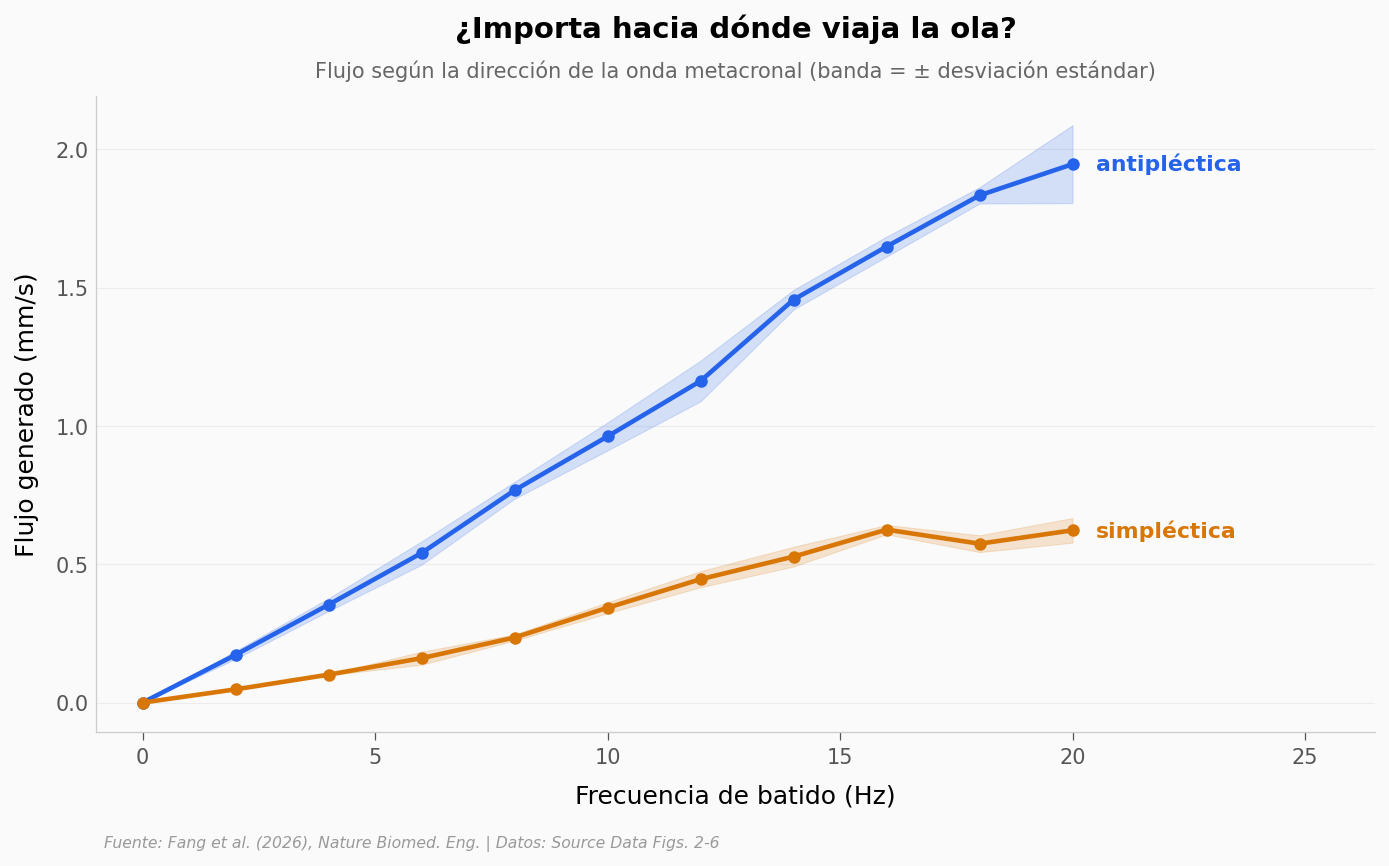

La antipléctica gana en 10/10 frecuencias medidas (se excluye 0 Hz: ambas dan 0).
Ratio antipléctica/simpléctica: mediana 3.16x (rango 2.61x - 3.60x)
A 20 Hz: antipléctica 1.9469 mm/s vs simpléctica 0.6230 mm/s

Caveat: la curva simpléctica no sube de forma monótona. Cae entre 16 Hz (0.6254 mm/s) y 18 Hz (0.5746 mm/s).


In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

series = [('antiplectica_mm_s', 'antiplectica_sd', COLOR_DATOS, 'antipléctica'),
          ('simplectica_mm_s', 'simplectica_sd', COLOR_REFERENCIA, 'simpléctica')]

for col, sd, color, etiqueta in series:
    ax.fill_between(onda.frecuencia_hz, onda[col] - onda[sd], onda[col] + onda[sd],
                    color=color, alpha=0.18, zorder=2)
    ax.plot(onda.frecuencia_hz, onda[col], color=color, lw=2.2, marker='o',
            ms=5, zorder=4)
    ax.text(onda.frecuencia_hz.iloc[-1] + 0.5, onda[col].iloc[-1], etiqueta,
            color=color, fontsize=10.5, fontweight='bold', va='center')

ax.set_xlim(-1, 26.5)
ax.set_xlabel('Frecuencia de batido (Hz)')
ax.set_ylabel('Flujo generado (mm/s)')
ax.set_title('¿Importa hacia dónde viaja la ola?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Flujo según la dirección de la onda metacronal (banda = ± desviación estándar)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/onda_metacronal.png', dpi=200, bbox_inches='tight')
plt.show()

ratio = (onda.antiplectica_mm_s / onda.simplectica_mm_s).replace([np.inf, -np.inf], np.nan).dropna()
gana = int((onda.antiplectica_mm_s > onda.simplectica_mm_s).sum())
comparables = int((onda.frecuencia_hz > 0).sum())
print(f'La antipléctica gana en {gana}/{comparables} frecuencias medidas (se excluye 0 Hz: ambas dan 0).')
print(f'Ratio antipléctica/simpléctica: mediana {ratio.median():.2f}x '
      f'(rango {ratio.min():.2f}x - {ratio.max():.2f}x)')
print(f'A {FRECUENCIA_MAX_HZ} Hz: antipléctica {onda.antiplectica_mm_s.iloc[-1]:.4f} mm/s '
      f'vs simpléctica {onda.simplectica_mm_s.iloc[-1]:.4f} mm/s')
print()
peor = onda.simplectica_mm_s.diff() < 0
print('Caveat: la curva simpléctica no sube de forma monótona. Cae entre '
      f'{onda.loc[peor, "frecuencia_hz"].iloc[0] - 2:.0f} Hz '
      f'({onda.simplectica_mm_s[peor.idxmax() - 1]:.4f} mm/s) y '
      f'{onda.loc[peor, "frecuencia_hz"].iloc[0]:.0f} Hz '
      f'({onda.simplectica_mm_s[peor.idxmax()]:.4f} mm/s).')

No lo es: la antipléctica gana en **las diez** frecuencias con batido (a 0 Hz las dos dan cero), con una mediana de 3,2 veces más flujo. La misma cantidad de cilios, batiendo a la misma velocidad, mueve tres veces más sangre solo por cambiar el sentido en que se propaga la ola.

## Si más cilios empujan más, ¿por qué no forrar el tubo entero?

El tapete no cubre toda la circunferencia del robot: cubre un arco. El equipo barrió ese arco desde 45° hasta 360° —el tubo completo— midiendo el flujo con partículas fluorescentes trazadoras. La intuición dice que más superficie activa debería dar más empuje.

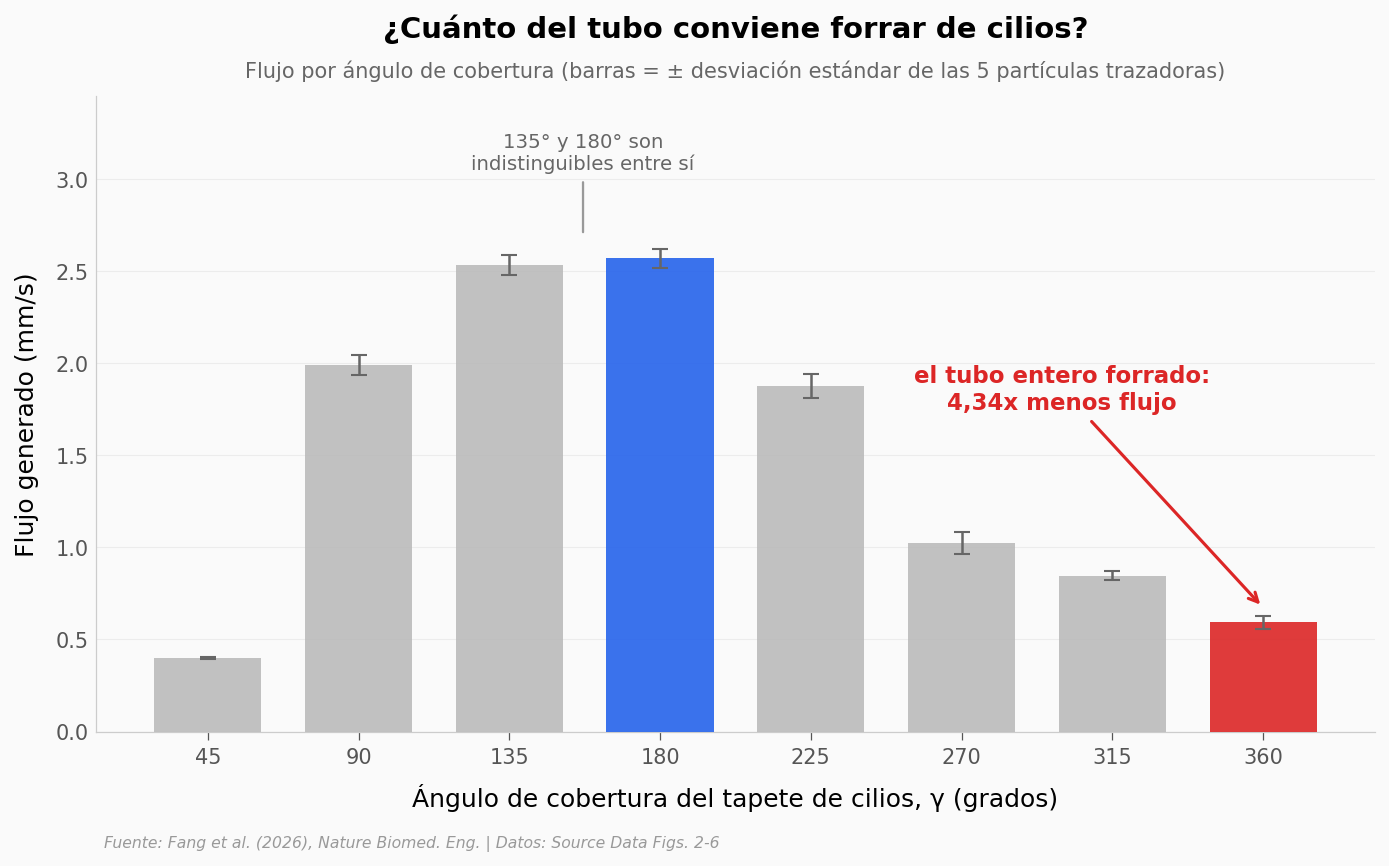

Máximo: γ=180° -> 2.5693 mm/s
Mínimo: γ=45° -> 0.3992 mm/s
Tubo completo (360°): 0.5924 mm/s -> 4.34x menos que el máximo

¿180° es realmente mejor que 135°? Diferencia = 0.0345 mm/s, con s.d. de 0.0499 y 0.0554.
La diferencia es MENOR que las propias desviaciones: con estos datos no se puede
declarar un ganador entre 135° y 180°. El hallazgo sólido es la caída hacia 360°.


In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

pico = cobertura.loc[cobertura.flujo_mm_s.idxmax()]
colores = [COLOR_ALERTA if g == 360 else (COLOR_DATOS if g == COBERTURA_DESTACADA else COLOR_CONTEXTO)
           for g in cobertura.cobertura_gamma_deg]

ax.bar(cobertura.cobertura_gamma_deg, cobertura.flujo_mm_s, width=32,
       color=colores, alpha=0.9, yerr=cobertura.flujo_sd, capsize=4,
       error_kw=dict(ecolor='#666666', lw=1.2), zorder=3)

fila_360 = cobertura.query('cobertura_gamma_deg == 360').iloc[0]
ratio_360 = pico.flujo_mm_s / fila_360.flujo_mm_s
ax.annotate(f'el tubo entero forrado:\n{ratio_360:.2f}x menos flujo'.replace('.', ','),
            xy=(360, fila_360.flujo_mm_s + 0.08), xytext=(300, 1.75),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA, ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))
ax.annotate('135° y 180° son\nindistinguibles entre sí',
            xy=(157, pico.flujo_mm_s + 0.12), xytext=(157, 3.05),
            fontsize=9.5, color='#666666', ha='center',
            arrowprops=dict(arrowstyle='-', color='#999999', lw=1.1))

ax.set_xticks(cobertura.cobertura_gamma_deg)
ax.set_xlabel('Ángulo de cobertura del tapete de cilios, γ (grados)')
ax.set_ylabel('Flujo generado (mm/s)')
ax.set_ylim(0, 3.45)
ax.set_title('¿Cuánto del tubo conviene forrar de cilios?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Flujo por ángulo de cobertura (barras = ± desviación estándar de las 5 partículas trazadoras)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cobertura_cilios.png', dpi=200, bbox_inches='tight')
plt.show()

fila_135 = cobertura.query('cobertura_gamma_deg == 135').iloc[0]
fila_min = cobertura.loc[cobertura.flujo_mm_s.idxmin()]
print(f'Máximo: γ={pico.cobertura_gamma_deg:.0f}° -> {pico.flujo_mm_s:.4f} mm/s')
print(f'Mínimo: γ={fila_min.cobertura_gamma_deg:.0f}° -> {fila_min.flujo_mm_s:.4f} mm/s')
print(f'Tubo completo (360°): {fila_360.flujo_mm_s:.4f} mm/s -> {ratio_360:.2f}x menos que el máximo')
print()
print(f'¿180° es realmente mejor que 135°? Diferencia = '
      f'{pico.flujo_mm_s - fila_135.flujo_mm_s:.4f} mm/s, '
      f'con s.d. de {pico.flujo_sd:.4f} y {fila_135.flujo_sd:.4f}.')
print('La diferencia es MENOR que las propias desviaciones: con estos datos no se puede')
print('declarar un ganador entre 135° y 180°. El hallazgo sólido es la caída hacia 360°.')

Cubrir medio tubo mueve **4,3 veces más** flujo que cubrirlo entero. Y tiene sentido apenas piensas en lo que hace un cilio: empuja fluido en una dirección. Si forras los 360°, los cilios de un lado empujan contra los del otro y el chorro neto se cancela. La asimetría no es un defecto del diseño — es el mecanismo.

## El flujo no disuelve el coágulo. El fármaco sí.

Entonces, ¿por qué se destapa antes? Porque el tPA tiene que **llegar** al coágulo. Sin flujo llega por difusión; con flujo llega arrastrado por la corriente, que es mucho más rápido. El equipo midió cuánto tPA hay dentro del coágulo a lo largo de 50 minutos, con y sin robot.

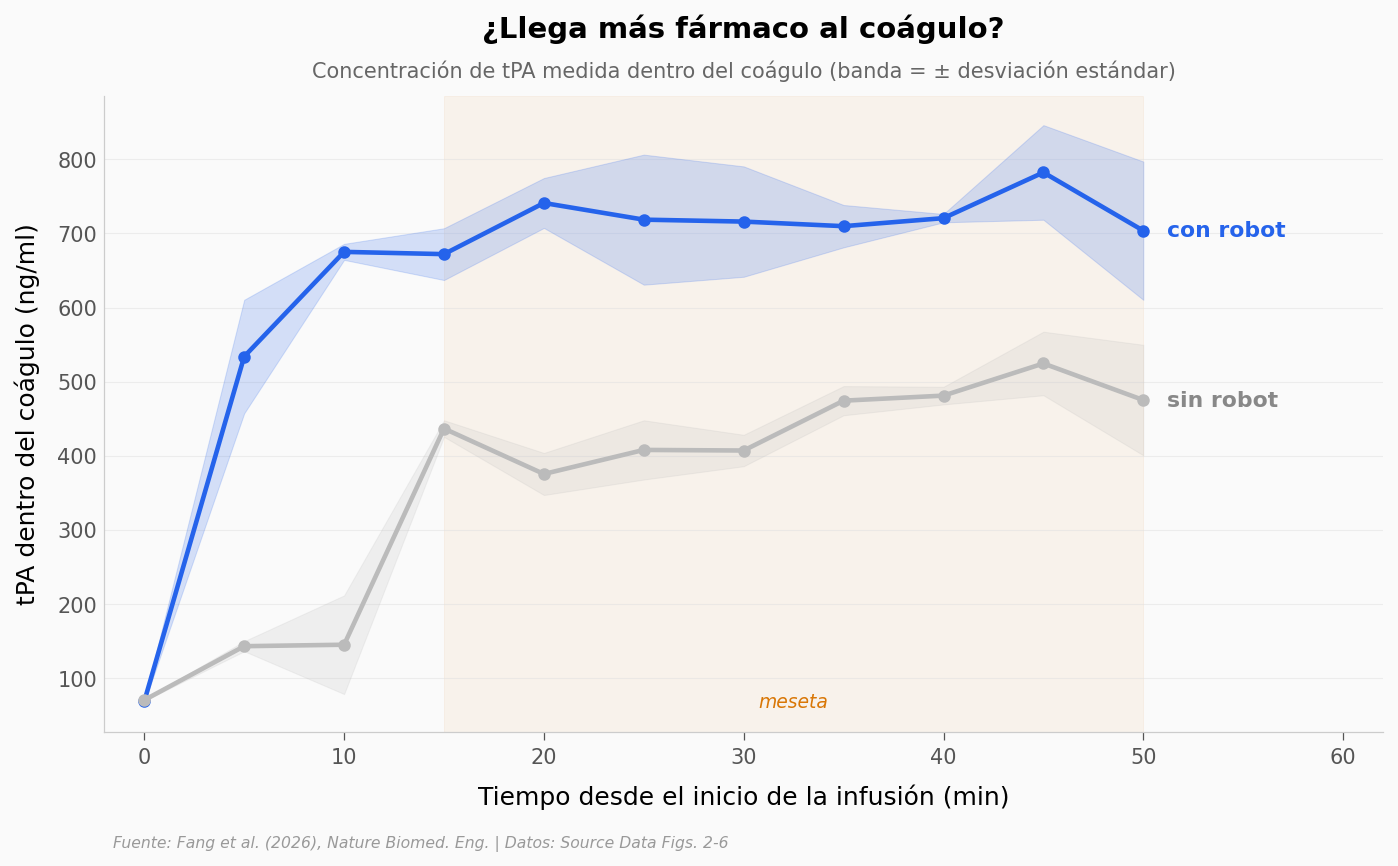

Punto de partida (minuto 0): sin robot 70.33 ng/ml, con robot 68.70 ng/ml -> ratio 0.98x
Arrancan a un 2.3% uno del otro (d de Cohen = 1.09).
Con 3 réplicas por punto esa diferencia no se distingue de cero, pero tampoco alcanza
para declarar equivalencia: es un control razonable, no un control probado.

El grupo con robot está por encima en 10/10 de los tiempos posteriores al inicio.
Área bajo la curva 0-50 min: con robot 33278, sin robot 18340 -> 1.81x
Meseta (15-50 min): con robot media 720.5 ng/ml (IQR 708.3-725.7), sin robot media 447.8 ng/ml (IQR 407.7-476.7) -> 1.61x

Caveat: el ratio máximo aparece en el minuto 10 (4.65x), pero ese punto
es frágil: el valor sin robot ahí es 145.0 ± 66.6 ng/ml (CV = 46%).
Para describir el efecto usamos la meseta y el área bajo la curva, no ese pico.


In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for col, sd, color, etiqueta in [('con_robot_ng_ml', 'con_robot_sd', COLOR_DATOS, 'con robot'),
                                 ('sin_robot_ng_ml', 'sin_robot_sd', COLOR_CONTEXTO, 'sin robot')]:
    ax.fill_between(tpa.tiempo_min, tpa[col] - tpa[sd], tpa[col] + tpa[sd],
                    color=color, alpha=0.18, zorder=2)
    ax.plot(tpa.tiempo_min, tpa[col], color=color, lw=2.2, marker='o', ms=5, zorder=4)
    ax.text(tpa.tiempo_min.iloc[-1] + 1.2, tpa[col].iloc[-1], etiqueta,
            color=color if color != COLOR_CONTEXTO else '#888888',
            fontsize=10.5, fontweight='bold', va='center')

ax.axvspan(VENTANA_MESETA_MIN, tpa.tiempo_min.max(), color=COLOR_REFERENCIA,
           alpha=0.06, zorder=1)
ax.text((VENTANA_MESETA_MIN + tpa.tiempo_min.max()) / 2, 60, 'meseta',
        fontsize=9, color=COLOR_REFERENCIA, ha='center', style='italic')

ax.set_xlim(-2, 62)
ax.set_xlabel('Tiempo desde el inicio de la infusión (min)')
ax.set_ylabel('tPA dentro del coágulo (ng/ml)')
ax.set_title('¿Llega más fármaco al coágulo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Concentración de tPA medida dentro del coágulo (banda = ± desviación estándar)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tpa_coagulo.png', dpi=200, bbox_inches='tight')
plt.show()

basal = tpa.query('tiempo_min == 0').iloc[0]
print(f'Punto de partida (minuto 0): sin robot {basal.sin_robot_ng_ml:.2f} ng/ml, '
      f'con robot {basal.con_robot_ng_ml:.2f} ng/ml -> ratio {basal.con_robot_ng_ml / basal.sin_robot_ng_ml:.2f}x')
d_basal = ((basal.con_robot_ng_ml - basal.sin_robot_ng_ml)
           / np.sqrt((basal.con_robot_sd ** 2 + basal.sin_robot_sd ** 2) / 2))
print(f'Arrancan a un {100 * abs(basal.con_robot_ng_ml / basal.sin_robot_ng_ml - 1):.1f}% uno del otro '
      f'(d de Cohen = {abs(d_basal):.2f}).')
print('Con 3 réplicas por punto esa diferencia no se distingue de cero, pero tampoco alcanza')
print('para declarar equivalencia: es un control razonable, no un control probado.')
print()

post = tpa.query('tiempo_min > 0')
print(f'El grupo con robot está por encima en {int((post.con_robot_ng_ml > post.sin_robot_ng_ml).sum())}'
      f'/{len(post)} de los tiempos posteriores al inicio.')

auc_con = trapz(tpa.con_robot_ng_ml, tpa.tiempo_min)
auc_sin = trapz(tpa.sin_robot_ng_ml, tpa.tiempo_min)
print(f'Área bajo la curva 0-50 min: con robot {auc_con:.0f}, sin robot {auc_sin:.0f} '
      f'-> {auc_con / auc_sin:.2f}x')

meseta = tpa.query('tiempo_min >= @VENTANA_MESETA_MIN')
mc, ms_ = meseta.con_robot_ng_ml, meseta.sin_robot_ng_ml
print(f'Meseta ({VENTANA_MESETA_MIN}-50 min): con robot media {mc.mean():.1f} ng/ml '
      f'(IQR {mc.quantile(.25):.1f}-{mc.quantile(.75):.1f}), '
      f'sin robot media {ms_.mean():.1f} ng/ml (IQR {ms_.quantile(.25):.1f}-{ms_.quantile(.75):.1f}) '
      f'-> {mc.mean() / ms_.mean():.2f}x')
print()

pico_t = post.assign(r=post.con_robot_ng_ml / post.sin_robot_ng_ml).sort_values('r').iloc[-1]
print(f'Caveat: el ratio máximo aparece en el minuto {pico_t.tiempo_min:.0f} ({pico_t.r:.2f}x), pero ese punto')
print(f'es frágil: el valor sin robot ahí es {pico_t.sin_robot_ng_ml:.1f} ± {pico_t.sin_robot_sd:.1f} ng/ml '
      f'(CV = {100 * pico_t.sin_robot_sd / pico_t.sin_robot_ng_ml:.0f}%).')
print('Para describir el efecto usamos la meseta y el área bajo la curva, no ese pico.')

Con robot entra alrededor de **1,6 veces** más tPA al coágulo durante la meseta, y 1,81 veces más si se integra toda la curva. No es el 4,7 del pico del minuto 10 — ese punto tiene una desviación del 46% y no aguanta que se apoye una frase en él.

## ¿Dónde pesa más el robot?

El equipo repitió el barrido de frecuencia con distintas velocidades en el vaso principal, desde una rama completamente parada hasta una con 15 mm/s de fondo. La pregunta es qué le añade el robot a cada una.

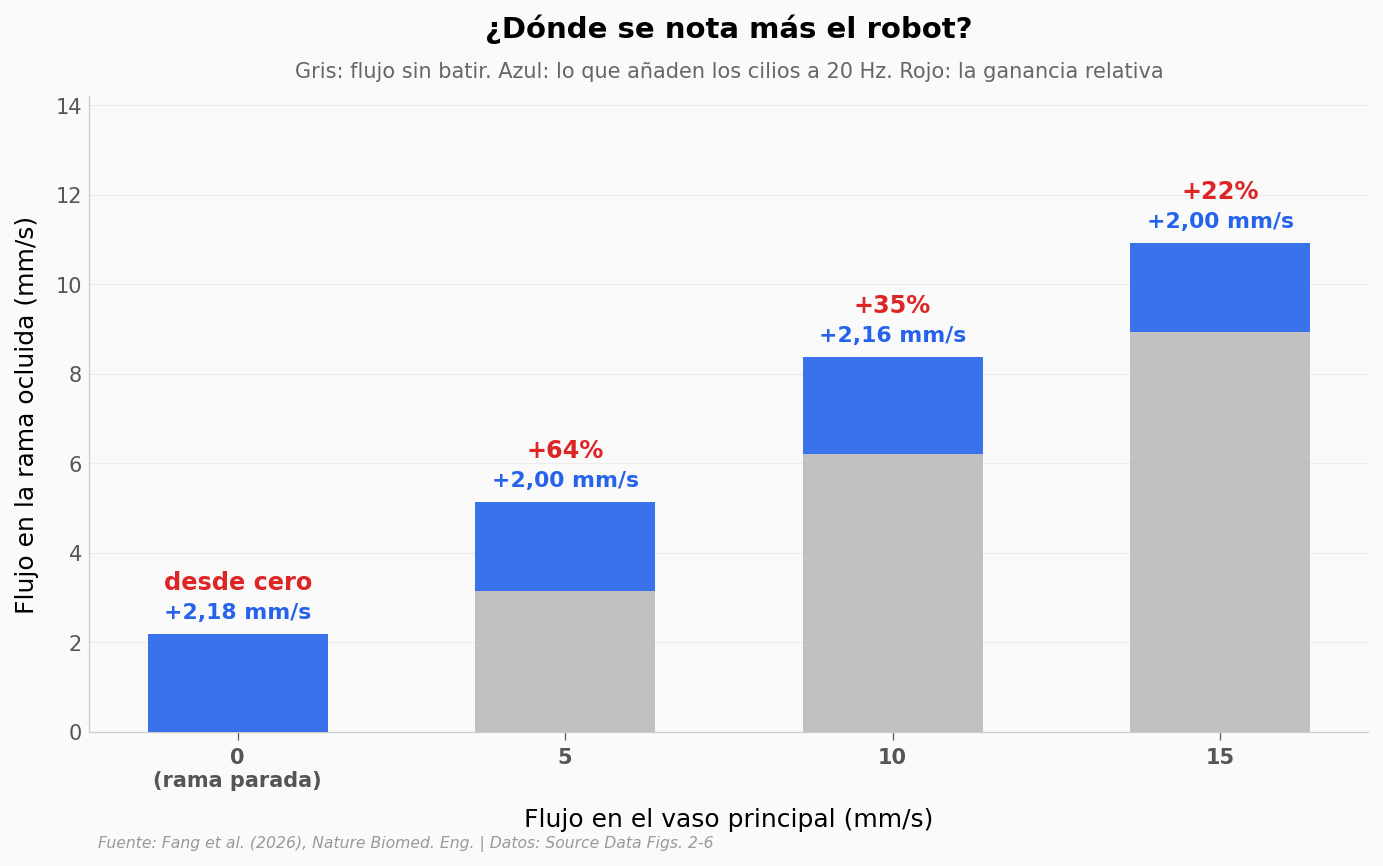

   Flujo de fondo |    base |  a 20 Hz |    ganancia |  relativa
----------------------------------------------------------------
           0 mm/s |    0.00 |     2.18 |   2.18 mm/s | no aplica
           5 mm/s |    3.13 |     5.13 |   2.00 mm/s |     63.9%
          10 mm/s |    6.21 |     8.37 |   2.16 mm/s |     34.8%
          15 mm/s |    8.92 |    10.92 |   2.00 mm/s |     22.4%

La ganancia absoluta se mueve entre 2.00 y 2.18 mm/s (rango de 0.18 mm/s).
La relativa se desploma al subir el flujo de fondo. Con la rama parada no hay
porcentaje que calcular: el robot crea flujo donde el valor de partida era exactamente 0.


In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))

regimenes = sorted(fondo.flujo_vaso_principal_mm_s.unique())
base, top = [], []
for v in regimenes:
    sub = fondo[fondo.flujo_vaso_principal_mm_s == v]
    base.append(float(sub[sub.frecuencia_hz == 0].flujo_rama_mm_s.iloc[0]))
    top.append(float(sub[sub.frecuencia_hz == FRECUENCIA_MAX_HZ].flujo_rama_mm_s.iloc[0]))
base, top = np.array(base), np.array(top)
delta = top - base

x = np.arange(len(regimenes))
ax.bar(x, base, color=COLOR_CONTEXTO, alpha=0.9, width=0.55, zorder=3)
ax.bar(x, delta, bottom=base, color=COLOR_DATOS, alpha=0.9, width=0.55, zorder=3)

for i, (b, d) in enumerate(zip(base, delta)):
    ax.text(i, b + d + 0.35, f'+{d:.2f} mm/s'.replace('.', ','), ha='center',
            fontsize=10.5, fontweight='bold', color=COLOR_DATOS)
    etiqueta = f'+{100 * d / b:.0f}%' if b > 0 else 'desde cero'
    ax.text(i, b + d + 1.0, etiqueta, ha='center', fontsize=11.5,
            fontweight='bold', color=COLOR_ALERTA)

ax.set_xticks(x)
ax.set_xticklabels(['0\n(rama parada)', '5', '10', '15'], fontsize=10, fontweight='bold')
ax.set_xlabel('Flujo en el vaso principal (mm/s)')
ax.set_ylabel('Flujo en la rama ocluida (mm/s)')
ax.set_ylim(0, 14.2)
ax.set_title('¿Dónde se nota más el robot?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Gris: flujo sin batir. Azul: lo que añaden los cilios a 20 Hz. Rojo: la ganancia relativa',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ganancia_por_flujo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'{"Flujo de fondo":>17} | {"base":>7} | {"a 20 Hz":>8} | {"ganancia":>11} | {"relativa":>9}')
print('-' * 64)
for v, b, t, d in zip(regimenes, base, top, delta):
    rel = f'{100 * d / b:.1f}%' if b > 0 else 'no aplica'
    print(f'{v:>12.0f} mm/s | {b:>7.2f} | {t:>8.2f} | {d:>6.2f} mm/s | {rel:>9}')
print()
print(f'La ganancia absoluta se mueve entre {delta.min():.2f} y {delta.max():.2f} mm/s '
      f'(rango de {delta.max() - delta.min():.2f} mm/s).')
print('La relativa se desploma al subir el flujo de fondo. Con la rama parada no hay')
print('porcentaje que calcular: el robot crea flujo donde el valor de partida era exactamente 0.')

El robot añade una cantidad casi fija —unos 2 mm/s— en los cuatro flujos de fondo que midieron, de 0 a 15 mm/s. Lo que cambia es qué tan grande resulta esa suma comparada con lo que ya había. En una rama con 15 mm/s de fondo son 2 mm/s sobre 9 — un 22%. En una rama parada, esos mismos 2 mm/s son todo el flujo que existe.

Es decir: el robot pesa más justo donde el vaso está peor.

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Con el robot, el vaso ocluido del cerdo se recanalizó en 45,0 min frente a 163,3 sin él (−72,4%) | ⚠️ | Separación total entre grupos (90 min de margen) y d de Cohen = 9,5 (g de Hedges = 7,6 al corregir el sesgo de muestra pequeña). Pero con n=3+3 el p exacto por permutación a dos colas es 0,10, que es el **mínimo aritméticamente alcanzable**. El efecto es enorme; el diseño no permite llamarlo significativo |
| In vitro el tiempo baja de 95,0 a 40,4 min (−57,5%) | ✅ | n=5+5, separación total, p exacto a dos colas = 0,008, d = 4,4 (g de Hedges = 4,0). Ese p también es el mínimo alcanzable con ese tamaño |
| La onda antipléctica genera más flujo que la simpléctica | ✅ | Gana en las 10 frecuencias medidas; mediana 3,16x (rango 2,61–3,60). La curva simpléctica no es monótona: cae entre 16 y 18 Hz |
| Cubrir medio tubo de cilios da más flujo que cubrirlo entero | ✅ | 2,57 mm/s a 180° frente a 0,59 mm/s a 360° (4,34x). ⚠️ 180° y 135° difieren en 0,03 mm/s, menos que sus propias desviaciones: entre esos dos no hay ganador |
| Con el robot llega más tPA al coágulo | ✅ | Área bajo la curva 1,81x; meseta 1,6x; por encima en los 10 tiempos posteriores al inicio, partiendo de basales casi iguales (70,3 vs 68,7 ng/ml). Son 3 réplicas técnicas por punto y sin valores crudos: no hay test posible, aunque con las desviaciones publicadas la d de Cohen de la meseta va de 2,7 a 25,8. ⚠️ el pico de 4,65x del minuto 10 no se usa: ese punto tiene un CV del 46% |
| La ganancia de flujo es casi constante en términos absolutos y decreciente en relativos | ✅ | +2,18 / +2,00 / +2,16 / +2,00 mm/s para fondos de 0 / 5 / 10 / 15 mm/s → +64% / +35% / +22% (con la rama parada el porcentaje no existe: se divide por cero) |

> **Limitaciones**
>
> - **Muestras muy pequeñas.** 3 animales por grupo in vivo, 5 réplicas por grupo in vitro. Ningún test de permutación a dos colas puede dar p < 0,10 con 3+3, ni p < 0,008 con 5+5.
> - **Los Source Data publican medias y desviaciones estándar, no mediciones individuales.** Solo las Figs. 5g y 6h (las dos de recanalización) traen los valores crudos por réplica. En los barridos de flujo de las Figs. 2–4 no se pueden recalcular tests: leemos las medias que publicó el paper.
> - **Alcance.** Phantoms de vaso con sangre porcina y un modelo porcino vivo. No hay datos en personas, ni esto es un tratamiento disponible.
> - **El paper está tras muro de pago.** El cuerpo y los Methods no son accesibles; el contexto no numérico sale del abstract y del Supplementary Information, que sí es libre.
> - **Nuestra verificación es interna.** Recalculamos medias y desviaciones desde los valores crudos y coinciden con las columnas Average/SD del propio Source Data en las dos hojas que los traen, Figs. 5g y 6h (discrepancia máxima: 0,03%, atribuible al redondeo de la tabla publicada). Eso confirma que leímos bien las hojas, no que el experimento sea correcto.

## Ahora tú

**1. ¿El robot pierde fuerza cuando el imán se aleja?** Los datos de `robot_velocidad_distancia.csv` miden la velocidad del robot con el imán entre 45 y 75 mm. Pista: `cargar('robot_velocidad_distancia.csv')` y grafica velocidad contra distancia.

**2. ¿"Más apretados" siempre significa "más flujo"?** El DataFrame `espaciado` tiene un grid de 4×4 de separaciones entre filas y columnas de cilios. Pista: `espaciado.pivot(index='espaciado_fila_L', columns='espaciado_columna_L', values='flujo_mm_s')` — mira si la tendencia se sostiene en las dos direcciones o solo en una.

**3. ¿Cuánto flujo en contra aguanta el robot antes de quedarse quieto?** `robot_velocidad_contraflujo.csv` mide la velocidad del robot con flujo opuesto de 0 a 25 mm/s, para tres velocidades de imán. Pista: agrupa por velocidad de imán y mira si las tres curvas convergen.

In [7]:
# --- EXPERIMENTA AQUÍ ---
# El abstract dice que navegar y regular el flujo están "desacoplados".
# Esta hoja (Fig. 5c) no mide el batido de los cilios, pero sí la otra mitad:
# cuánto del tirón del imán se convierte en avance según el ángulo de actuación.

pivote = iman.pivot(index='velocidad_iman_mm_s',
                    columns='angulo_actuacion_deg',
                    values='velocidad_robot_mm_s')
print('Velocidad del robot (mm/s) según el ángulo de actuación:')
print(pivote.round(2).to_string())
print()

rapido = pivote.index.max()
fila = pivote.loc[rapido]
print(f'Con el imán a {rapido:.0f} mm/s:')
print(f'  actuación a 0°  -> el robot avanza {fila[0]:.2f} mm/s')
print(f'  actuación a 60° -> el robot avanza {fila[60]:.2f} mm/s  ({fila[0] / fila[60]:.2f}x menos)')
print()
lento = pivote[60].replace(0, np.nan).min()
print(f'A 60° el robot sigue avanzando —de {lento:.2f} a {fila[60]:.2f} mm/s según acelera el imán—,')
print(f'pero {fila[0] / fila[60]:.2f}x más lento que a 0°. El ángulo de actuación gradúa cuánto del')
print('tirón magnético se convierte en avance; el batido de los cilios no se mide aquí.')

# Tu turno: prueba a graficar las tres curvas, o a repetir esto con
# robot_velocidad_contraflujo.csv para ver dónde el flujo le gana al imán.

Velocidad del robot (mm/s) según el ángulo de actuación:
angulo_actuacion_deg     0     30    60
velocidad_iman_mm_s                    
0                      0.00  0.00  0.00
5                      4.19  4.20  3.12
10                     7.15  6.51  4.04
15                     9.59  7.82  4.44
20                    10.10  8.77  4.85
25                    11.98  9.13  4.84
30                    13.14  9.46  5.25

Con el imán a 30 mm/s:
  actuación a 0°  -> el robot avanza 13.14 mm/s
  actuación a 60° -> el robot avanza 5.25 mm/s  (2.50x menos)

A 60° el robot sigue avanzando —de 3.12 a 5.25 mm/s según acelera el imán—,
pero 2.50x más lento que a 0°. El ángulo de actuación gradúa cuánto del
tirón magnético se convierte en avance; el batido de los cilios no se mide aquí.


---

## Fuentes

**Paper**: [A miniature endovascular soft robot for active blood flow regulation in occluded vessels](https://doi.org/10.1038/s41551-026-01771-y)  
*Nature Biomedical Engineering, 2026-08-17 · paywall*

**Source Data**: [Source Data Figs. 2–6 — A miniature endovascular soft robot for active blood flow regulation in occluded vessels](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41551-026-01771-y/MediaObjects/41551_2026_1771_MOESM11_ESM.xlsx)

**Supplementary Material**: [Supplementary Information — Notes 1–3 y Figs. S1–S24](https://media.springernature.com/original/springer-static/esm/art%3A10.1038%2Fs41551-026-01771-y/MediaObjects/41551_2026_1771_MOESM1_ESM.pdf)

*19 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repositorio:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · notebook reproducible, datos incluidos.

*El Lab de [Ciencia a Mordiscos](https://cienciaamordiscos.com). Si algo aquí está mal, se corrige.*